***APPENDIX***

**Rhianna Ruggiero**

**Humamn Resources Data Model**

In [662]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [664]:
#read data into python
df = pd.read_csv("HRDataset_v14.csv")

In [666]:
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [668]:
#check for missing values
df.isnull().sum()

Employee_Name                   0
EmpID                           0
MarriedID                       0
MaritalStatusID                 0
GenderID                        0
EmpStatusID                     0
DeptID                          0
PerfScoreID                     0
FromDiversityJobFairID          0
Salary                          0
Termd                           0
PositionID                      0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
CitizenDesc                     0
HispanicLatino                  0
RaceDesc                        0
DateofHire                      0
DateofTermination             207
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
ManagerID                       8
RecruitmentSource               0
PerformanceSco

It makes sense that there would be missing values for date of termination since those employees are likely still with the company, however this column will also cause data leakage and will be removed. Manager ID can also be dropped since the same information is essentially contained in Manager Name.

In [671]:
#create a column that states whether an employee voluntarily terminated or not (since we are not interested in the other factors specifically)
df["VoluntarilyLeft"] = np.where(
    df["EmploymentStatus"].str.contains("Voluntarily", case=False, na=False),
    1,
    0
)

In [673]:
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences,VoluntarilyLeft
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1,0
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17,1
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3,1
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15,0
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2,1


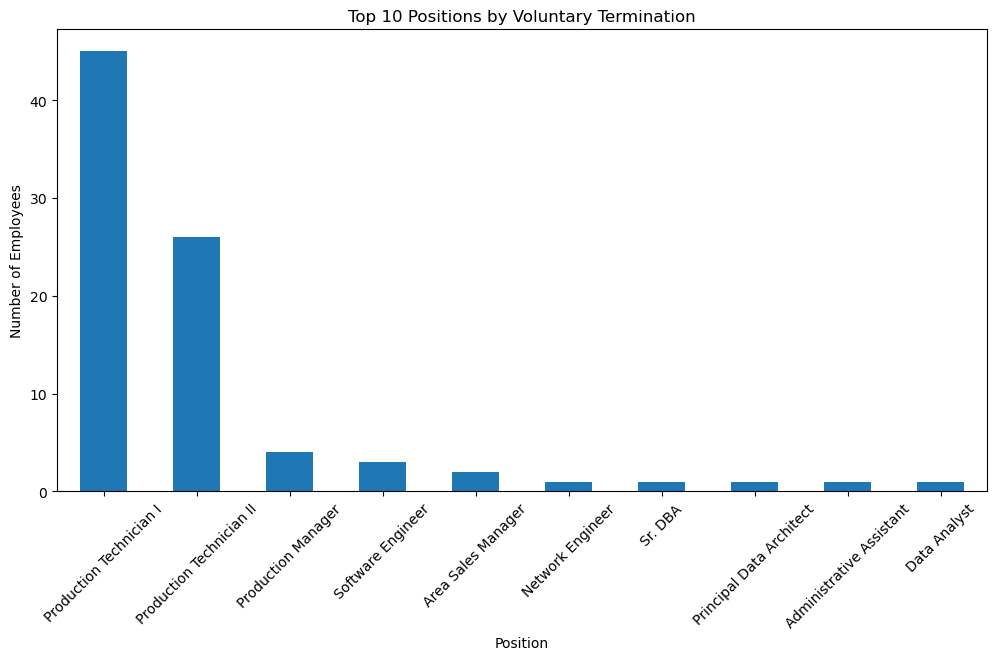

In [675]:
df["VoluntarilyLeft"] = df["EmploymentStatus"].str.contains("Voluntarily").astype(int)

df.groupby("Position")["VoluntarilyLeft"].sum().sort_values(ascending=False).head(10).plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Positions by Voluntary Termination")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.show()

In [677]:
#drop unnecessary columns that either cause leakage or don't provide useful information
drop_cols = [
    "Employee_Name",
    "EmpID",
    "TermReason",
    "DateofTermination",
    "EmploymentStatus",
    "LastPerformanceReview_Date",
    "ManagerID",
    "PositionID",
    "DeptID",
    "EmpStatusID",
    "Zip",
    "DOB",
    "MaritalStatusID",
    "MarriedID",
    "Termd"
    #last performance review date could indicate that an employee left since they will have an old date in this column
]

df = df.drop(columns=drop_cols)

In [679]:
print(df.dtypes)

GenderID                    int64
PerfScoreID                 int64
FromDiversityJobFairID      int64
Salary                      int64
Position                   object
State                      object
Sex                        object
MaritalDesc                object
CitizenDesc                object
HispanicLatino             object
RaceDesc                   object
DateofHire                 object
Department                 object
ManagerName                object
RecruitmentSource          object
PerformanceScore           object
EngagementSurvey          float64
EmpSatisfaction             int64
SpecialProjectsCount        int64
DaysLateLast30              int64
Absences                    int64
VoluntarilyLeft             int32
dtype: object


In [681]:
df["DateofHire"].dtype

dtype('O')

Date of hire could be an important column to see if length of time in the role has an effect, so I will change the date to a tenure column.

In [684]:
df["DateofHire"] = pd.to_datetime(df["DateofHire"])

df["Tenure"] = (pd.Timestamp.today() - df["DateofHire"]).dt.days

df = df.drop(columns=["DateofHire"])

In [686]:
df.head()

,GenderID,PerfScoreID,FromDiversityJobFairID,Salary,Position,State,Sex,MaritalDesc,CitizenDesc,HispanicLatino,...,ManagerName,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,VoluntarilyLeft,Tenure
0,1,4,0,62506,Production Technician I,MA,M,Single,US Citizen,No,...,Michael Albert,LinkedIn,Exceeds,4.60,5,0,0,1,0,5437
1,1,3,0,104437,Sr. DBA,MA,M,Married,US Citizen,No,...,Simon Roup,Indeed,Fully Meets,4.96,3,6,0,17,1,4073
2,0,3,0,64955,Production Technician II,MA,F,Married,US Citizen,No,...,Kissy Sullivan,LinkedIn,Fully Meets,3.02,3,0,0,3,1,5437
3,0,3,0,64991,Production Technician I,MA,F,Married,US Citizen,No,...,Elijiah Gray,Indeed,Fully Meets,4.84,5,0,0,15,0,6712
4,0,3,0,50825,Production Technician I,MA,F,Divorced,US Citizen,No,...,Webster Butler,Google Search,Fully Meets,5.00,4,0,0,2,1,5431


In [688]:
#many columns are categorical and need to be encoded
df = pd.get_dummies(df, drop_first=True)

In [690]:
df = df.astype(int, errors='ignore')

In [692]:
X = df.drop("VoluntarilyLeft", axis=1)
y = df["VoluntarilyLeft"]

In [694]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
    #stratify used for class imbalance
)

In [696]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [698]:
model = LogisticRegression(
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [700]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [702]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.78      0.82        45
           1       0.57      0.72      0.63        18

    accuracy                           0.76        63
   macro avg       0.72      0.75      0.73        63
weighted avg       0.79      0.76      0.77        63



In [704]:
print(confusion_matrix(y_test, y_pred))

[[35 10]
 [ 5 13]]


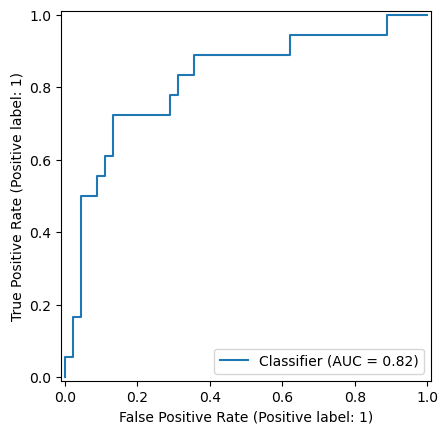

In [706]:
RocCurveDisplay.from_predictions(y_test, y_prob)

plt.show()

In [708]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients.sort_values(by="Coefficient", ascending=False))

                                 Feature  Coefficient
9                                 Tenure     1.667250
7                         DaysLateLast30     0.669456
88                  ManagerName_Amy Dunn     0.664280
82                        RaceDesc_White     0.658006
62                              State_TN     0.570966
..                                   ...          ...
112           RecruitmentSource_LinkedIn    -0.598926
6                   SpecialProjectsCount    -0.600584
69                   MaritalDesc_Married    -0.660127
109  RecruitmentSource_Employee Referral    -0.772638
71                    MaritalDesc_Single    -0.865414

[119 rows x 2 columns]


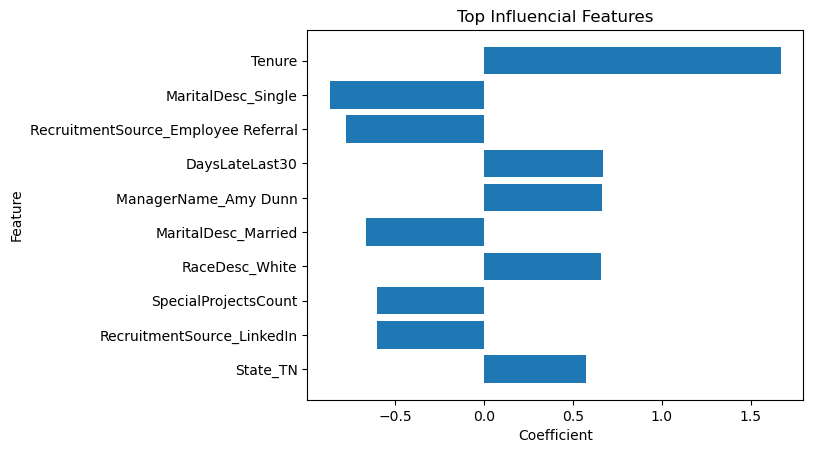

In [710]:
# top positive and negative drivers
top_coeffs = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
).head(10)

plt.barh(top_coeffs["Feature"], top_coeffs["Coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Influencial Features")
plt.gca().invert_yaxis()

plt.show()